In [5]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [6]:
df = pd.read_csv("salaries for VIF.csv")


In [10]:
df.head()

,Years of Experience,Education Level,Age,Location Factor,Salary
0,29,1,49,7,124204
1,27,3,45,4,125948
2,20,4,41,8,116078
3,14,4,37,5,106486
4,20,3,42,7,113297


<Axes: >

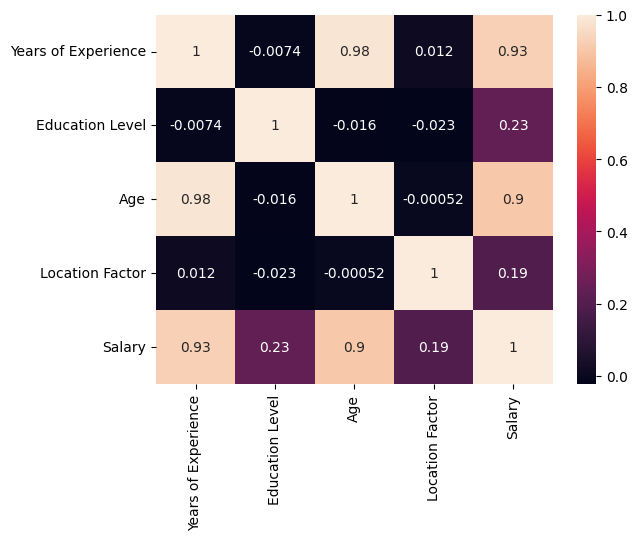

In [11]:
sns.heatmap(df.corr() , annot = True )

In [12]:
x = df.drop(["Salary"] , axis = 1 )
y = df["Salary"]


In [13]:
from sklearn.model_selection import  train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state= 20)

In [14]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
model.coef_

array([2101.28064312, 5106.54850397, -102.23856978, 1490.23420719])

In [16]:
# calculate VIF

In [17]:
df1 = df.drop("Salary" , axis=1)

In [18]:
df1.shape

(1000, 4)

In [21]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 744.9 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/9.5 MB 744.9 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.5 MB 798.6 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.5 MB 880.7 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.5 MB 911.4 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.5 MB 950.4 kB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.5 MB 997.8 kB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.5 MB 1.0 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.5 MB 1.0 MB/s eta 0:00:08
   --------- -------------

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [23]:
df1.columns

Index(['Years of Experience', 'Education Level', 'Age', 'Location Factor'], dtype='object')

In [26]:
def calculateVIF(df1):
    result = pd.DataFrame()
    result["Input variable"] = df1.columns
    vif=[]
    for i in range(df1.shape[1]):
        vif.append(variance_inflation_factor(df1,i))
    result['vif values'] = vif
    return result 
    

In [27]:
calculateVIF(df1)

,Input variable,vif values
0,Years of Experience,22.342087
1,Education Level,5.472969
2,Age,42.201149
3,Location Factor,4.289467


In [29]:
df1=df1.drop("Age" , axis = 1)

In [30]:
calculateVIF(df1)

,Input variable,vif values
0,Years of Experience,3.198601
1,Education Level,3.509425
2,Location Factor,3.231181
